In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
df=pd.read_csv('data_science_job.csv')

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [5]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [7]:
cols=[var for var in df.columns if df[var].isnull().mean()<0.05 and  df[var].isnull().mean()>0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [9]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
2855,0.624,Full time course,High School,5.0,91.0
16721,0.624,no_enrollment,Graduate,6.0,23.0
14160,0.920,no_enrollment,Graduate,16.0,58.0
18466,0.767,no_enrollment,Masters,9.0,61.0
584,0.698,no_enrollment,Masters,7.0,98.0


In [10]:
df['education_level'].value_counts()

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

In [11]:
df['enrolled_university'].value_counts()

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64

In [12]:
len(df[cols].dropna())/len(df)

0.8968577095730244

In [13]:
#only 10 percent data has been droped so we can perform cca (complete case analysis) 


In [17]:
new_df=df[cols].dropna()
df.shape,new_df.shape 


((19158, 13), (17182, 5))

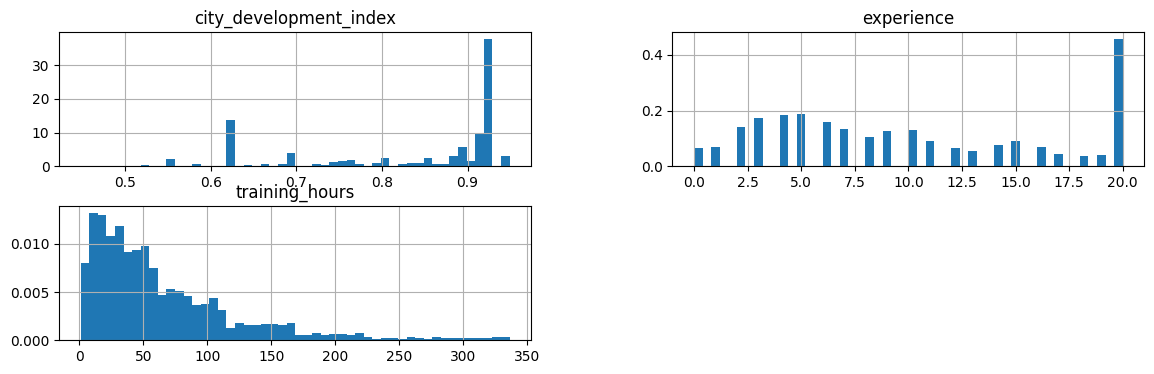

In [18]:
new_df.hist(bins=50,density=True,figsize=(14,4))
plt.show()

<Axes: >

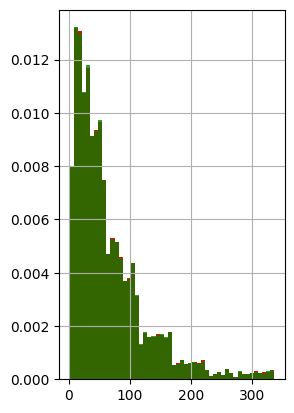

In [20]:
fig=plt.figure() 
ax=fig.add_subplot(121) 

#original data 

df['training_hours'].hist(bins=50,density=True,ax=ax,color="red")

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions

new_df['training_hours'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: ylabel='Density'>

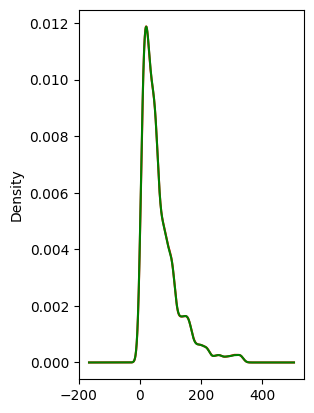

In [22]:
fig=plt.figure() 
ax=fig.add_subplot(121) 

#original data 
df['training_hours'].plot.density(color='red') 

#cca data 
new_df['training_hours'].plot.density(color='green')

<Axes: >

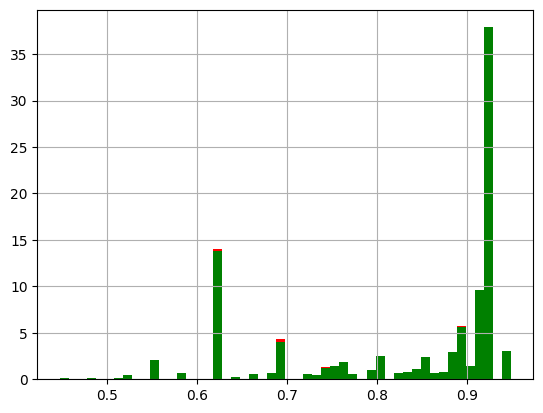

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111) 

# original data

df['city_development_index'].hist(bins=50,density=True,ax=ax,color='red')


#cca data 
new_df['city_development_index'].hist(bins=50,density=True,ax=ax,color='green')

<Axes: >

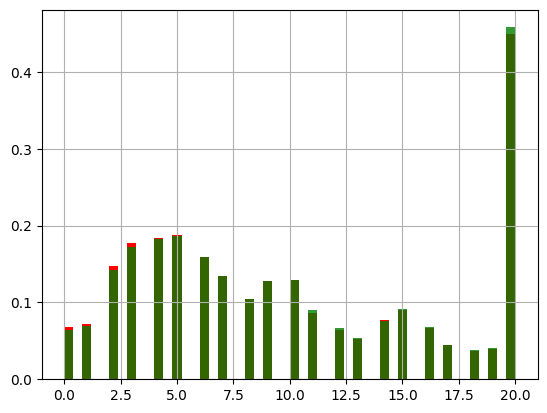

In [25]:

fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['experience'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

# categorical data analysis 



In [29]:
temp=pd.concat([
    #percentage of observation per category ,original data 

    df['education_level'].value_counts()/len(df) , 

    #percaentage of observation per category ,cca data 

    new_df['education_leve'].value_counts()/len(new_df)
],axis=1)

temp.columns=['original','cca']
temp

KeyError: 'education_leve'

In [ ]:
temp=pd.concat([
    #percentage of observation per category ,original data 

    df['enrolled_university'].value_counts()/len(df) , 

    #percaentage of observation per category ,cca data 

    new_df['enrolled_university'].value_counts()/len(new_df)
],axis=1)

temp.columns=['original','cca']
temp